In [1]:

import sys
import torch
import torchvision
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Training will use CPU.")

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu
NumPy: 2.0.0
Pandas: 2.2.3

CUDA available: False
Training will use CPU.


In [2]:

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

PROCESSED_DIR = PROJECT_ROOT / "ml" / "data" / "processed"
TRAIN_DIR = PROCESSED_DIR / "Training"
TEST_DIR = PROCESSED_DIR / "Testing"

CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images(folder):
    if not folder.exists():
        return 0

    return sum(
        1 for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

rows = []

for split_name, split_dir in [
    ("Training", TRAIN_DIR),
    ("Testing", TEST_DIR)
]:
    for class_name in CLASSES:
        class_dir = split_dir / class_name

        rows.append({
            "Split": split_name,
            "Class": class_name,
            "Images": count_images(class_dir)
        })

dataset_df = pd.DataFrame(rows)

print("Processed dataset:", PROCESSED_DIR)
display(dataset_df)

print("\nTotal images:", dataset_df["Images"].sum())
print("\nCounts by split:")
display(dataset_df.groupby("Split")["Images"].sum().to_frame())

Processed dataset: D:\Projects\Medexplain_AI\ml\data\processed


,Split,Class,Images
0,Training,glioma,1400
1,Training,meningioma,1386
2,Training,notumor,1281
3,Training,pituitary,1362
4,Testing,glioma,386
5,Testing,meningioma,398
6,Testing,notumor,400
7,Testing,pituitary,400



Total images: 7013

Counts by split:


,Images
Split,
Testing,1584
Training,5429


In [3]:

import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42
BATCH_SIZE = 16
IMAGE_SIZE = 224

torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Device: cpu


In [4]:

train_full_dataset = datasets.ImageFolder(
    root=str(TRAIN_DIR),
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=str(TEST_DIR),
    transform=eval_transform
)

print("Class mapping:", train_full_dataset.class_to_idx)
print("Training samples:", len(train_full_dataset))
print("Testing samples:", len(test_dataset))
print("Test class mapping:", test_dataset.class_to_idx)

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training samples: 5429
Testing samples: 1584
Test class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [5]:

from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

targets = train_full_dataset.targets
indices = np.arange(len(targets))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=targets
)

train_dataset = Subset(train_full_dataset, train_indices)
val_dataset = Subset(train_full_dataset, val_indices)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 4343
Validation samples: 1086
Test samples: 1584


In [6]:

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Batches — train:", len(train_loader))
print("Batches — validation:", len(val_loader))
print("Batches — test:", len(test_loader))

Batches — train: 272
Batches — validation: 68
Batches — test: 99


In [7]:

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels in batch:", labels.tolist())
print("Class names:", train_full_dataset.classes)

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Labels in batch: [3, 1, 1, 2, 1, 3, 2, 0, 1, 0, 1, 1, 2, 2, 2, 0]
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [8]:

import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

NUM_CLASSES = 4

weights = EfficientNet_B0_Weights.DEFAULT

try:
    model = efficientnet_b0(weights=weights)
    print("Loaded EfficientNet-B0 with ImageNet pretrained weights.")
except Exception as e:
    print("Could not load pretrained weights:", repr(e))
    print("Loading EfficientNet-B0 without pretrained weights.")
    model = efficientnet_b0(weights=None)

# Replace the classifier for our four classes
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(device)

print("\nClassifier:", model.classifier)
print("Device:", device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Kanak/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:07<00:00, 2.91MB/s]

Loaded EfficientNet-B0 with ImageNet pretrained weights.

Classifier: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)
Device: cpu


In [9]:

model.eval()

with torch.no_grad():
    sample_images, sample_labels = next(iter(train_loader))
    sample_images = sample_images.to(device)

    outputs = model(sample_images)

print("Input shape:", sample_images.shape)
print("Output shape:", outputs.shape)
print("Expected output shape:", (BATCH_SIZE, NUM_CLASSES))

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 4])
Expected output shape: (16, 4)


In [13]:

import torch.optim as optim
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

LEARNING_RATE = 1e-4
NUM_EPOCHS = 10

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Learning rate:", LEARNING_RATE)
print("Epochs:", NUM_EPOCHS)
print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Learning rate: 0.0001
Epochs: 10
Loss: CrossEntropyLoss()
Optimizer: Adam


In [14]:
# Freeze the pretrained feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Keep the classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

# Count trainable and total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

# Configure loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

print("\nTraining configuration ready.")

Total parameters: 4,012,672
Trainable parameters: 5,124
Frozen parameters: 4,007,548

Training configuration ready.


In [16]:
# Training configuration
EPOCHS = 10
LEARNING_RATE = 0.0001

print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Epochs: 10
Learning rate: 0.0001


In [18]:
# Get the class mapping from the original ImageFolder dataset
class_to_idx = train_loader.dataset.dataset.class_to_idx

print("Class mapping:", class_to_idx)

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [19]:
from pathlib import Path
import copy
import time
import json
import torch

# ==========================================
# 1. OUTPUT DIRECTORIES
# ==========================================

PROJECT_ROOT = Path.cwd().parent.parent

CHECKPOINT_DIR = PROJECT_ROOT / "ml" / "results" / "checkpoints"
METRICS_DIR = PROJECT_ROOT / "ml" / "results" / "metrics"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = CHECKPOINT_DIR / "efficientnet_b0_best.pth"
HISTORY_PATH = METRICS_DIR / "efficientnet_b0_training_history.json"


# ==========================================
# 2. GET CLASS MAPPING
# ==========================================

# train_loader.dataset is a Subset.
# Its underlying dataset is the original ImageFolder.
class_to_idx = train_loader.dataset.dataset.class_to_idx

print("Class mapping:", class_to_idx)


# ==========================================
# 3. INITIALIZE TRAINING TRACKING
# ==========================================

best_val_accuracy = 0.0
best_epoch = 0

best_model_state = copy.deepcopy(model.state_dict())

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}


# ==========================================
# 4. TRAINING LOOP
# ==========================================

for epoch in range(EPOCHS):

    start_time = time.time()

    # --------------------------------------
    # TRAINING
    # --------------------------------------

    model.train()

    # Keep the frozen feature extractor in eval mode
    model.features.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total


    # --------------------------------------
    # VALIDATION
    # --------------------------------------

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # --------------------------------------
    # SAVE METRICS
    # --------------------------------------

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)


    # --------------------------------------
    # SAVE BEST CHECKPOINT
    # --------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        best_model_state = copy.deepcopy(model.state_dict())

        torch.save(
            {
                "model_name": "EfficientNet-B0",
                "model_state_dict": best_model_state,
                "class_to_idx": class_to_idx,
                "best_val_accuracy": best_val_accuracy,
                "epoch": best_epoch,
                "learning_rate": LEARNING_RATE,
                "num_classes": NUM_CLASSES
            },
            CHECKPOINT_PATH
        )


    # --------------------------------------
    # PRINT EPOCH RESULTS
    # --------------------------------------

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {elapsed:.1f}s"
    )


# ==========================================
# 5. SAVE COMPLETE TRAINING HISTORY
# ==========================================

with open(HISTORY_PATH, "w", encoding="utf-8") as f:

    json.dump(history, f, indent=4)


# ==========================================
# 6. TRAINING SUMMARY
# ==========================================

print("\n" + "=" * 50)
print("EFFICIENTNET-B0 TRAINING COMPLETED")
print("=" * 50)

print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best validation accuracy (%): {best_val_accuracy * 100:.2f}%")
print(f"Best epoch: {best_epoch}")

print(f"\nCheckpoint saved at:\n{CHECKPOINT_PATH}")
print(f"\nTraining history saved at:\n{HISTORY_PATH}")

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Epoch [1/10] | Train Loss: 0.6490 | Train Acc: 0.8176 | Val Loss: 0.5739 | Val Acc: 0.8389 | Time: 182.3s
Epoch [2/10] | Train Loss: 0.5297 | Train Acc: 0.8407 | Val Loss: 0.4935 | Val Acc: 0.8564 | Time: 184.4s
Epoch [3/10] | Train Loss: 0.4633 | Train Acc: 0.8561 | Val Loss: 0.4410 | Val Acc: 0.8683 | Time: 181.1s
Epoch [4/10] | Train Loss: 0.4177 | Train Acc: 0.8683 | Val Loss: 0.4070 | Val Acc: 0.8757 | Time: 244.5s
Epoch [5/10] | Train Loss: 0.3870 | Train Acc: 0.8777 | Val Loss: 0.3833 | Val Acc: 0.8738 | Time: 195.3s
Epoch [6/10] | Train Loss: 0.3661 | Train Acc: 0.8791 | Val Loss: 0.3648 | Val Acc: 0.8849 | Time: 180.1s
Epoch [7/10] | Train Loss: 0.3463 | Train Acc: 0.8826 | Val Loss: 0.3477 | Val Acc: 0.8858 | Time: 188.2s
Epoch [8/10] | Train Loss: 0.3291 | Train Acc: 0.8904 | Val Loss: 0.3358 | Val Acc: 0.8886 | Time: 177.2s
Epoch [9/10] | Train Loss: 0.3169 | Train Acc: 0.8962 | Val Loss: 0.3237 | V

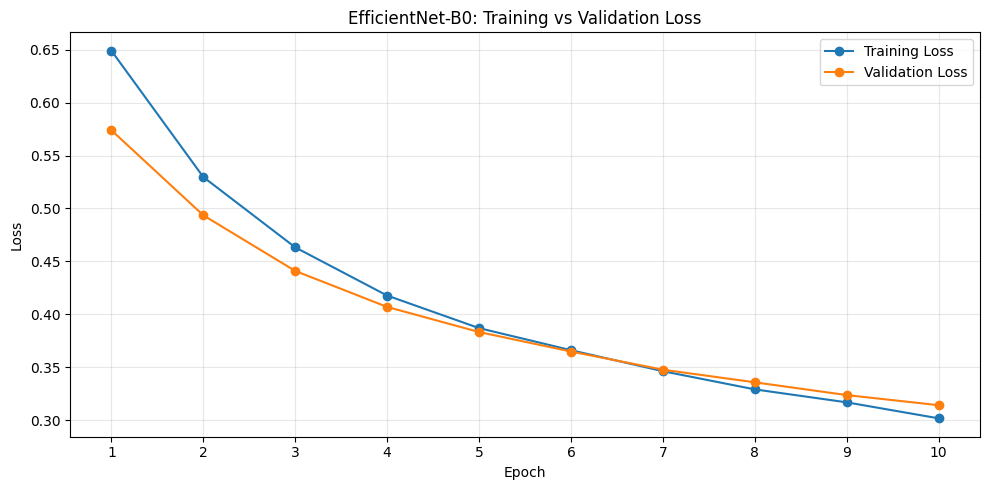

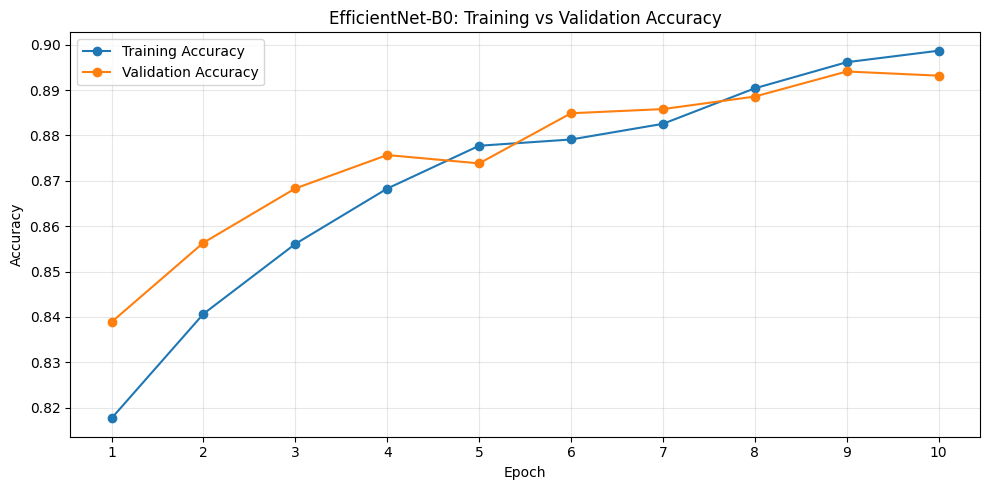

In [20]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

# --------------------------------
# 1. Training and Validation Loss
# --------------------------------

plt.figure(figsize=(10, 5))

plt.plot(epochs, history["train_loss"], marker="o",
         label="Training Loss")

plt.plot(epochs, history["val_loss"], marker="o",
         label="Validation Loss")

plt.title("EfficientNet-B0: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --------------------------------
# 2. Training and Validation Accuracy
# --------------------------------

plt.figure(figsize=(10, 5))

plt.plot(epochs, history["train_accuracy"], marker="o",
         label="Training Accuracy")

plt.plot(epochs, history["val_accuracy"], marker="o",
         label="Validation Accuracy")

plt.title("EfficientNet-B0: Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:

from pathlib import Path
import torch

# Re-establish the device and checkpoint directory
PROJECT_ROOT = Path.cwd().parent.parent
CHECKPOINT_DIR = PROJECT_ROOT / "ml" / "results" / "checkpoints"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Checkpoint directory exists:", CHECKPOINT_DIR.exists())
print("Checkpoint file exists:",
      (CHECKPOINT_DIR / "efficientnet_b0_best.pth").exists())

Device: cpu
Checkpoint directory exists: True
Checkpoint file exists: True


In [25]:

# Freeze all feature-extractor parameters
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze the final two feature blocks
for block in model.features[6:]:
    for param in block.parameters():
        param.requires_grad = True

# Keep classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

# Fine-tuning configuration
FINE_TUNE_LR = 1e-5
FINE_TUNE_EPOCHS = 5

# Use a lower learning rate for fine-tuning
optimizer = optim.Adam([
    {
        "params": [
            p for p in model.features.parameters()
            if p.requires_grad
        ],
        "lr": FINE_TUNE_LR
    },
    {
        "params": model.classifier.parameters(),
        "lr": FINE_TUNE_LR
    }
])

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print("Final two feature blocks unfrozen")
print("Trainable parameters:", f"{trainable_params:,}")
print("Fine-tuning learning rate:", FINE_TUNE_LR)
print("Fine-tuning epochs:", FINE_TUNE_EPOCHS)

Final two feature blocks unfrozen
Trainable parameters: 3,160,864
Fine-tuning learning rate: 1e-05
Fine-tuning epochs: 5


In [24]:

print("Checkpoint keys:", checkpoint.keys())
print("Best validation accuracy:", checkpoint["best_val_accuracy"])

Checkpoint keys: dict_keys(['model_name', 'model_state_dict', 'class_to_idx', 'best_val_accuracy', 'epoch', 'learning_rate', 'num_classes'])
Best validation accuracy: 0.8941068139963168


In [27]:

# Use the class mapping already stored in your loaded checkpoint
CLASS_TO_IDX = checkpoint["class_to_idx"]

print("Class mapping:", CLASS_TO_IDX)

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [28]:

# ==========================================
# EfficientNet-B0 Fine-Tuning
# ==========================================

# Confirm required variables exist
required_vars = [
    "model", "checkpoint", "CHECKPOINT_DIR", "METRICS_DIR",
    "DEVICE", "FINE_TUNE_EPOCHS", "optimizer",
    "criterion", "train_loader", "val_loader"
]

missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise NameError(f"Missing variables: {missing_vars}")

# Use the class mapping from the original checkpoint
CLASS_TO_IDX = checkpoint["class_to_idx"]

FINETUNED_CHECKPOINT = (
    CHECKPOINT_DIR / "efficientnet_b0_finetuned_best.pth"
)
FINETUNE_HISTORY_PATH = (
    METRICS_DIR / "efficientnet_b0_finetuning_history.json"
)

# Start from the original validation accuracy
best_finetune_accuracy = checkpoint["best_val_accuracy"]
best_finetune_epoch = checkpoint["epoch"]

finetune_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "epoch_time_seconds": []
}

print("Starting fine-tuning...")
print(f"Baseline validation accuracy: {best_finetune_accuracy:.4f}")
print(f"Baseline epoch: {best_finetune_epoch}")

for epoch in range(FINE_TUNE_EPOCHS):
    start_time = time.time()

    # -------------------------
    # Training
    # -------------------------
    model.train()

    # Keep frozen early feature blocks in eval mode
    for block in model.features[:6]:
        block.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    epoch_time = time.time() - start_time

    finetune_history["train_loss"].append(train_loss)
    finetune_history["train_accuracy"].append(train_accuracy)
    finetune_history["val_loss"].append(val_loss)
    finetune_history["val_accuracy"].append(val_accuracy)
    finetune_history["epoch_time_seconds"].append(epoch_time)

    print(
        f"Epoch [{epoch + 1}/{FINE_TUNE_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time / 60:.2f} min"
    )

    # -------------------------
    # Save improved best model
    # -------------------------
    if val_accuracy > best_finetune_accuracy:
        best_finetune_accuracy = val_accuracy
        best_finetune_epoch = epoch + 1

        torch.save(
            {
                "model_name": "EfficientNet-B0 Fine-Tuned",
                "model_state_dict": copy.deepcopy(model.state_dict()),
                "class_to_idx": CLASS_TO_IDX,
                "best_val_accuracy": best_finetune_accuracy,
                "epoch": best_finetune_epoch,
                "learning_rate": FINE_TUNE_LR,
                "num_classes": NUM_CLASSES
            },
            FINETUNED_CHECKPOINT
        )

        print("  Improved fine-tuned checkpoint saved!")

    # Save history after every epoch
    with open(FINETUNE_HISTORY_PATH, "w") as f:
        json.dump(finetune_history, f, indent=4)

print("\n" + "=" * 50)
print("FINE-TUNING COMPLETED")
print("=" * 50)
print(f"Original best validation accuracy: "
      f"{checkpoint['best_val_accuracy']:.4f}")
print(f"Best fine-tuning validation accuracy: "
      f"{best_finetune_accuracy:.4f}")
print(f"Best fine-tuning epoch: {best_finetune_epoch}")
print("Fine-tuned checkpoint:", FINETUNED_CHECKPOINT)
print("Fine-tuning history:", FINETUNE_HISTORY_PATH)

Starting fine-tuning...
Baseline validation accuracy: 0.8941
Baseline epoch: 9
Epoch [1/5] Train Loss: 0.3364 | Train Acc: 0.8936 | Val Loss: 0.2491 | Val Acc: 0.9134 | Time: 8.29 min
  Improved fine-tuned checkpoint saved!
Epoch [2/5] Train Loss: 0.2729 | Train Acc: 0.9107 | Val Loss: 0.2013 | Val Acc: 0.9291 | Time: 8.69 min
  Improved fine-tuned checkpoint saved!
Epoch [3/5] Train Loss: 0.2338 | Train Acc: 0.9245 | Val Loss: 0.1715 | Val Acc: 0.9392 | Time: 8.05 min
  Improved fine-tuned checkpoint saved!
Epoch [4/5] Train Loss: 0.2055 | Train Acc: 0.9314 | Val Loss: 0.1558 | Val Acc: 0.9392 | Time: 7.71 min
Epoch [5/5] Train Loss: 0.1722 | Train Acc: 0.9434 | Val Loss: 0.1322 | Val Acc: 0.9549 | Time: 7.37 min
  Improved fine-tuned checkpoint saved!

FINE-TUNING COMPLETED
Original best validation accuracy: 0.8941
Best fine-tuning validation accuracy: 0.9549
Best fine-tuning epoch: 5
Fine-tuned checkpoint: d:\Projects\Medexplain_AI\ml\results\checkpoints\efficientnet_b0_finetuned_be

In [29]:
import json
from pathlib import Path

history_path = Path("../results/metrics/efficientnet_b0_finetuning_history.json")

with open(history_path, "r") as f:
    finetune_history = json.load(f)

print("History loaded successfully!")
print("Available keys:", finetune_history.keys())

print("\nHistory contents:")
print(json.dumps(finetune_history, indent=2))

History loaded successfully!
Available keys: dict_keys(['train_loss', 'train_accuracy', 'val_loss', 'val_accuracy', 'epoch_time_seconds'])

History contents:
{
  "train_loss": [
    0.3363928938554285,
    0.27291702904405885,
    0.23375916110805012,
    0.20550235398431102,
    0.17216431389402168
  ],
  "train_accuracy": [
    0.8936219203315681,
    0.910660833525213,
    0.9244761685470873,
    0.9313838360580244,
    0.9433571264103154
  ],
  "val_loss": [
    0.24908780788875856,
    0.20133583640772335,
    0.17153332367690338,
    0.155826975438833,
    0.13217278208041608
  ],
  "val_accuracy": [
    0.9134438305709024,
    0.929097605893186,
    0.9392265193370166,
    0.9392265193370166,
    0.9548802946593001
  ],
  "epoch_time_seconds": [
    497.50529742240906,
    521.124311208725,
    483.2525382041931,
    462.4154715538025,
    442.3549575805664
  ]
}


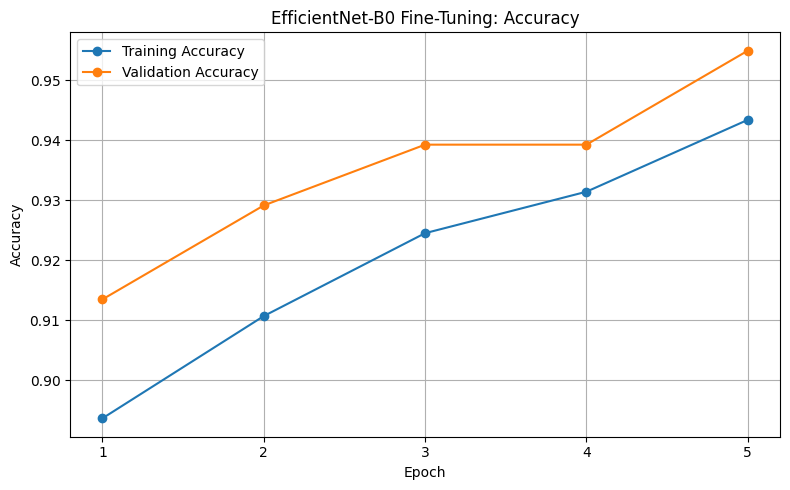

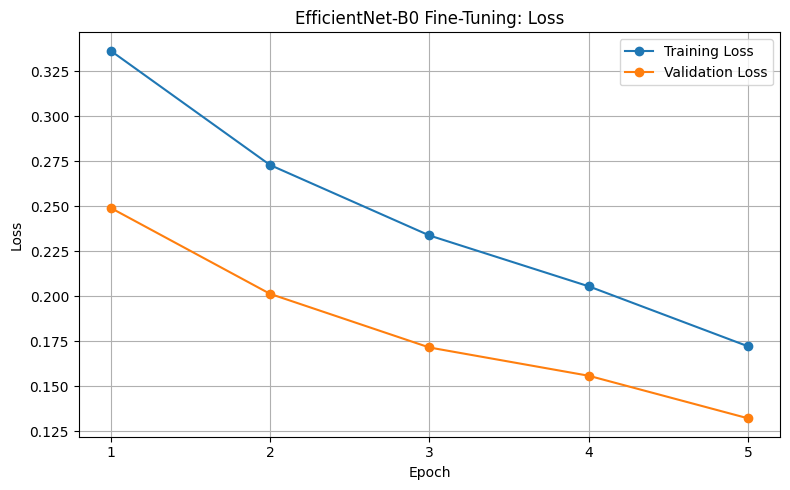

In [30]:
import matplotlib.pyplot as plt

epochs = range(1, len(finetune_history["train_loss"]) + 1)

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, finetune_history["train_accuracy"], marker="o", label="Training Accuracy")
plt.plot(epochs, finetune_history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("EfficientNet-B0 Fine-Tuning: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, finetune_history["train_loss"], marker="o", label="Training Loss")
plt.plot(epochs, finetune_history["val_loss"], marker="o", label="Validation Loss")
plt.title("EfficientNet-B0 Fine-Tuning: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from pathlib import Path

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Paths
test_dir = Path("../data/processed/Testing")
checkpoint_path = Path("../results/checkpoints/efficientnet_b0_finetuned_best.pth")

# Image transformations
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load test dataset
test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

print("Test images:", len(test_dataset))
print("Classes:", test_dataset.classes)
print("Class mapping:", test_dataset.class_to_idx)

# Load EfficientNet-B0 architecture
model = models.efficientnet_b0(weights=None)

# Replace classifier
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    4
)

# Load fine-tuned checkpoint
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

model = model.to(device)
model.eval()

print("\nFine-tuned EfficientNet-B0 loaded successfully!")
print("Checkpoint validation accuracy:",
      checkpoint["best_val_accuracy"])
print("Checkpoint epoch:",
      checkpoint["epoch"])

Device: cpu
Test images: 1584
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Fine-tuned EfficientNet-B0 loaded successfully!
Checkpoint validation accuracy: 0.9548802946593001
Checkpoint epoch: 5


In [32]:
from torch.utils.data import DataLoader
import numpy as np
import time

# Test DataLoader
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

all_predictions = []
all_labels = []
all_probabilities = []

model.eval()

start_time = time.time()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        # Convert logits to probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # Predicted class
        predictions = torch.argmax(probabilities, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

elapsed_time = time.time() - start_time

# Convert to NumPy arrays
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probabilities = np.array(all_probabilities)

print("Prediction completed successfully!")
print("Total test images evaluated:", len(all_labels))
print("Prediction time: {:.2f} seconds".format(elapsed_time))

print("\nPrediction array shape:", all_predictions.shape)
print("Label array shape:", all_labels.shape)
print("Probability array shape:", all_probabilities.shape)

Prediction completed successfully!
Total test images evaluated: 1584
Prediction time: 129.83 seconds

Prediction array shape: (1584,)
Label array shape: (1584,)
Probability array shape: (1584, 4)


In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Overall metrics
test_accuracy = accuracy_score(all_labels, all_predictions)

test_precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted"
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted"
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print("===== FINAL TEST PERFORMANCE =====")
print(f"Test Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall   : {test_recall:.4f}")
print(f"Test F1-score : {test_f1:.4f}")

print("\n===== CLASSIFICATION REPORT =====")

class_names = test_dataset.classes

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

===== FINAL TEST PERFORMANCE =====
Test Accuracy : 0.9217 (92.17%)
Test Precision: 0.9260
Test Recall   : 0.9217
Test F1-score : 0.9201

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      glioma     0.9739    0.7720    0.8613       386
  meningioma     0.8522    0.9271    0.8881       398
     notumor     0.9089    0.9975    0.9511       400
   pituitary     0.9704    0.9850    0.9777       400

    accuracy                         0.9217      1584
   macro avg     0.9263    0.9204    0.9195      1584
weighted avg     0.9260    0.9217    0.9201      1584



Confusion Matrix:
[[298  58  26   4]
 [  7 369  14   8]
 [  1   0 399   0]
 [  0   6   0 394]]


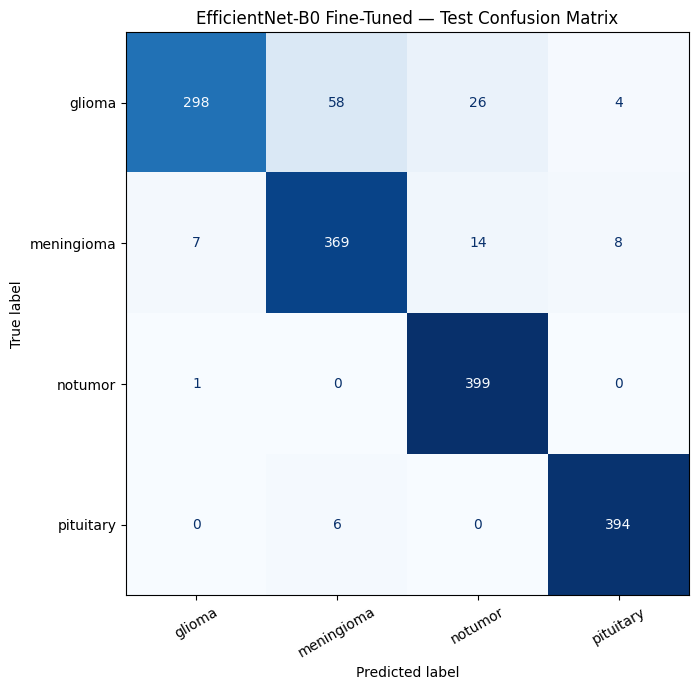

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

class_names = test_dataset.classes

cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=list(range(len(class_names)))
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("EfficientNet-B0 Fine-Tuned — Test Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Total misclassified images: 124
Total correctly classified images: 1460


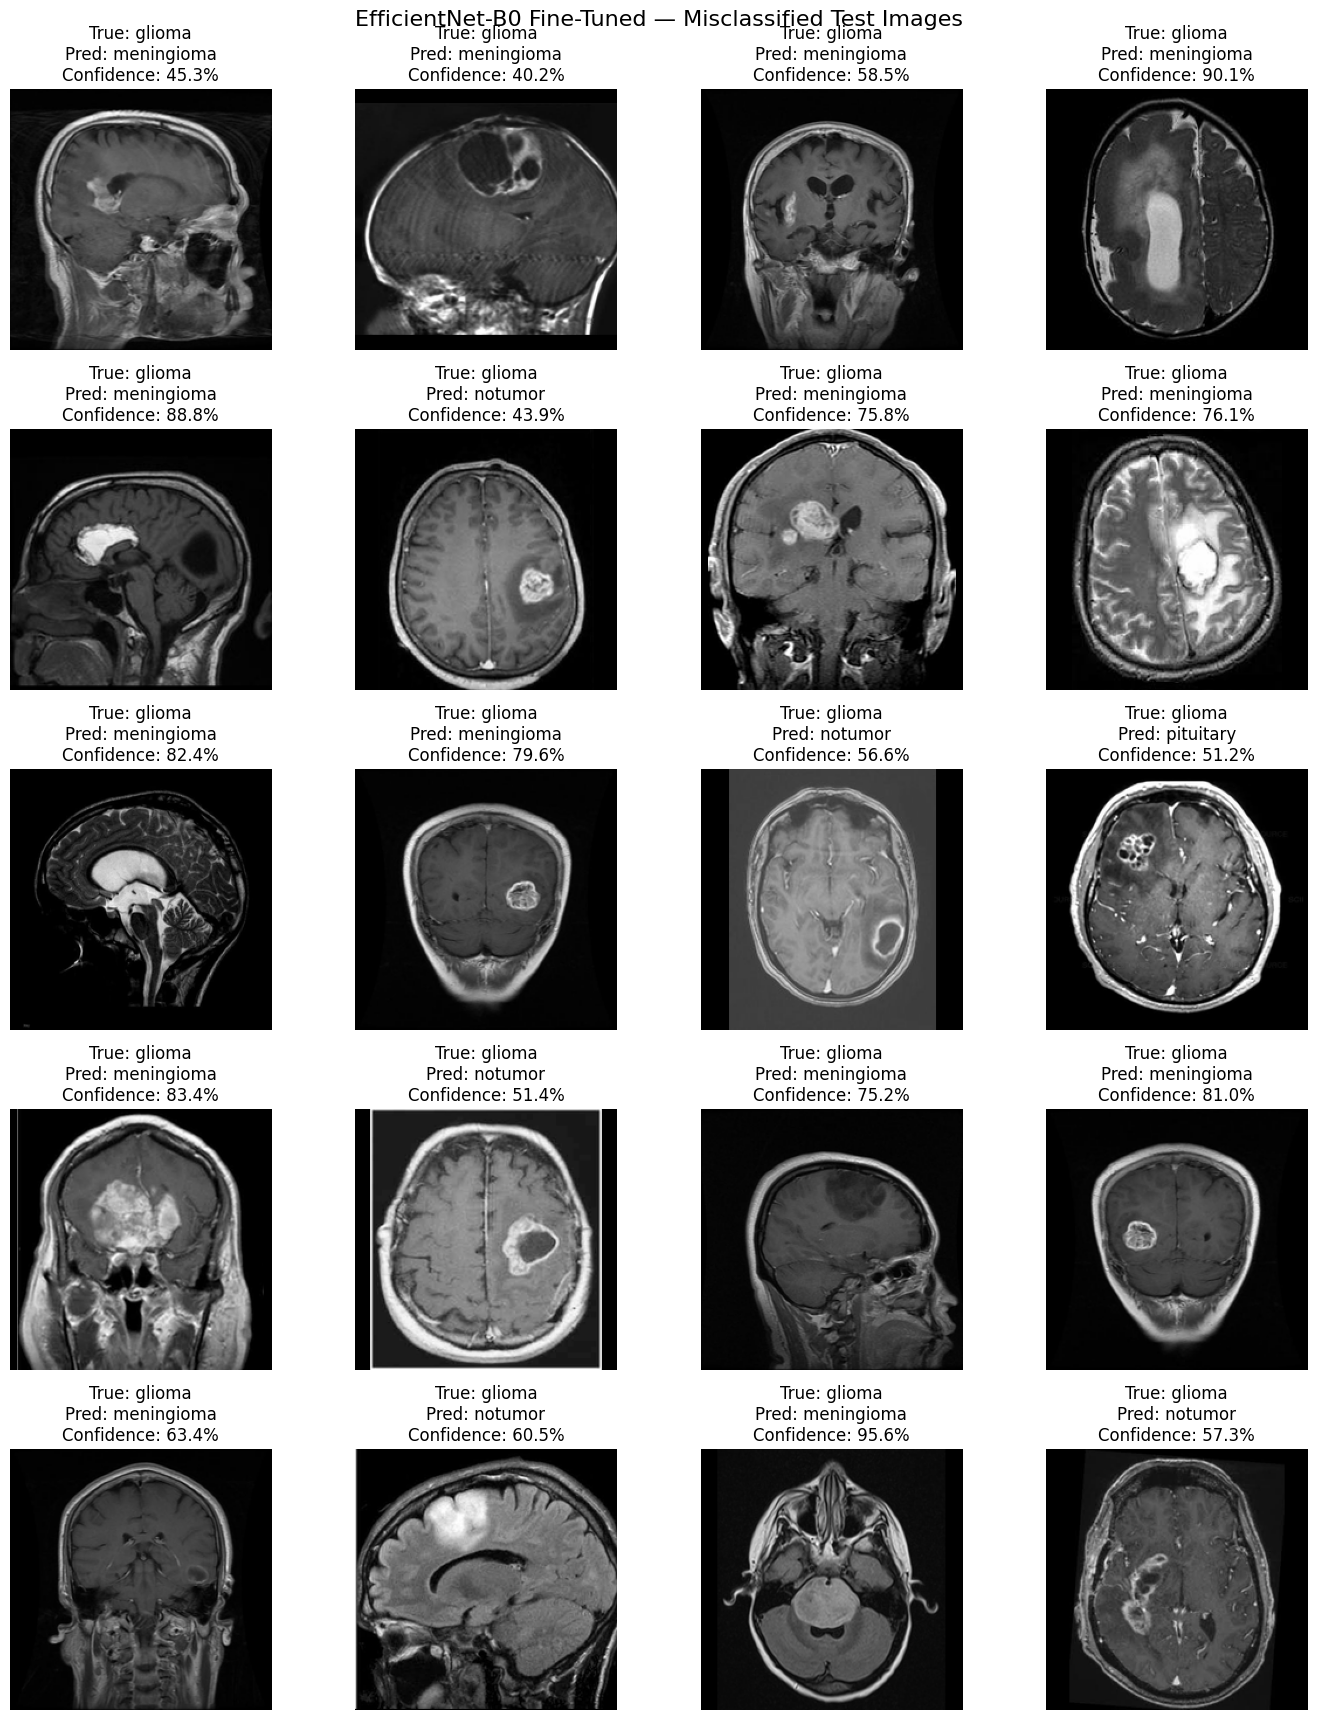

In [35]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import math

# Find all misclassified samples
misclassified_indices = np.where(all_labels != all_predictions)[0]

print("Total misclassified images:", len(misclassified_indices))
print("Total correctly classified images:", len(all_labels) - len(misclassified_indices))

# Show first 20 misclassified images
num_to_show = min(20, len(misclassified_indices))

cols = 4
rows = math.ceil(num_to_show / cols)

plt.figure(figsize=(14, rows * 3.5))

for plot_idx, dataset_idx in enumerate(misclassified_indices[:num_to_show]):

    image_path = test_dataset.samples[dataset_idx][0]

    image = Image.open(image_path).convert("RGB")

    true_class = class_names[all_labels[dataset_idx]]
    predicted_class = class_names[all_predictions[dataset_idx]]

    confidence = all_probabilities[dataset_idx][all_predictions[dataset_idx]]

    ax = plt.subplot(rows, cols, plot_idx + 1)

    ax.imshow(image)

    ax.set_title(
        f"True: {true_class}\n"
        f"Pred: {predicted_class}\n"
        f"Confidence: {confidence * 100:.1f}%"
    )

    ax.axis("off")

plt.suptitle(
    "EfficientNet-B0 Fine-Tuned — Misclassified Test Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [36]:
import json
from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Output directory
results_dir = Path("../results/metrics")
results_dir.mkdir(parents=True, exist_ok=True)

# Recalculate final metrics
final_metrics = {
    "model": "EfficientNet-B0 Fine-Tuned",
    "checkpoint_epoch": 5,
    "test_samples": int(len(all_labels)),
    "correct_predictions": int((all_labels == all_predictions).sum()),
    "misclassified_predictions": int((all_labels != all_predictions).sum()),
    "test_accuracy": float(accuracy_score(all_labels, all_predictions)),
    "weighted_precision": float(
        precision_score(all_labels, all_predictions, average="weighted")
    ),
    "weighted_recall": float(
        recall_score(all_labels, all_predictions, average="weighted")
    ),
    "weighted_f1_score": float(
        f1_score(all_labels, all_predictions, average="weighted")
    ),
    "macro_f1_score": float(
        f1_score(all_labels, all_predictions, average="macro")
    ),
    "class_names": class_names,
    "confusion_matrix": confusion_matrix(
        all_labels, all_predictions
    ).tolist(),
    "classification_report": classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        output_dict=True
    )
}

# Save JSON
output_path = results_dir / "efficientnet_b0_finetuned_test_results.json"

with open(output_path, "w") as f:
    json.dump(final_metrics, f, indent=4)

print("Final evaluation results saved!")
print("File:", output_path.resolve())
print("Test accuracy:", f"{final_metrics['test_accuracy'] * 100:.2f}%")
print("Misclassified images:", final_metrics["misclassified_predictions"])

Final evaluation results saved!
File: D:\Projects\Medexplain_AI\ml\results\metrics\efficientnet_b0_finetuned_test_results.json
Test accuracy: 92.17%
Misclassified images: 124
